<a href="https://colab.research.google.com/github/Rhodes-11/Landslide_Detection/blob/main/Landslide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

# from google.colab import auth
# auth.authenticate_user()

Mounted at /content/gdrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir(r'/content/gdrive/MyDrive/DL/landslide4Sense')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Testing the dataset
path_single = r"data/img/image_2000.h5"
path_single_mask = r'data/mask/mask_2000.h5'

ls ['img']
input data shape: (128, 128, 14)
data ndvi shape  (128, 128) f_data shape:  (1, 128, 128, 3)


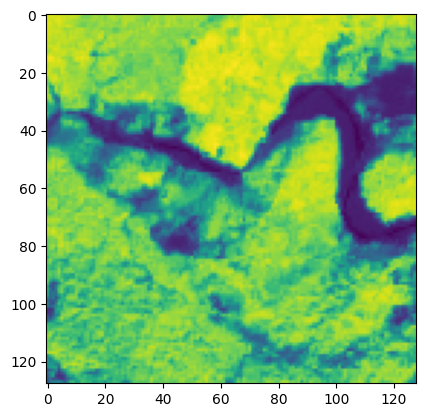

In [ ]:
f_data = np.zeros((1, 128,128, 3))
with h5py.File(path_single) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('img'))
    print("input data shape:", data.shape)
    plt.imshow(data[:, :, 3:0:-1])

    data_red = data[:, :, 3]
    data_green = data[:, :, 2]
    data_blue = data[:, :, 1]
    data_nir = data[:, :, 7]
    data_rgb = data[:, :, 3:0:-1]
    data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))
    f_data[0, :, :, 0] =data_ndvi
    f_data[0, :, :, 1] = data[:, :, 12]
    f_data[0, :, :, 2] = data[:, :, 13]

    print("data ndvi shape ", data_ndvi.shape, "f_data shape: ", f_data.shape)
    plt.imshow(data_ndvi)

ls ['mask']
input data shape: (128, 128)


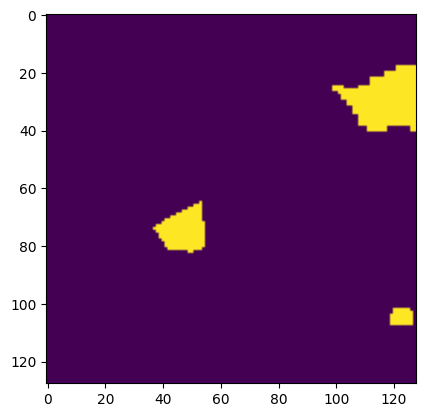

In [ ]:
with h5py.File(path_single_mask) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('mask'))
    print("input data shape:", data.shape)
    plt.imshow(data)

In [ ]:
path_single = r"data/img/image_10.h5"
path_single_mask = r'data/mask/mask_1.h5'
TRAIN_PATH = r"data/img/*.h5"
TRAIN_MASK = r'data/mask/*.h5'

TRAIN_XX = np.zeros((3799, 128, 128, 6))
TRAIN_YY = np.zeros((3799, 128, 128, 1))
all_train = sorted(glob.glob(TRAIN_PATH))
all_mask = sorted(glob.glob(TRAIN_MASK))

In [ ]:
#testing for google colab GPU
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
import numpy as np
import glob

TRAIN_PATH = r"data/img/*.h5"
TRAIN_MASK = r'data/mask/*.h5'

TRAIN_XX = np.zeros((3799, 128, 128, 6))
TRAIN_YY = np.zeros((3799, 128, 128, 1))
all_train = sorted(glob.glob(TRAIN_PATH))
all_mask = sorted(glob.glob(TRAIN_MASK))

for i, (img, mask) in enumerate(zip(all_train, all_mask)):
    print(i, img, mask)
    with h5py.File(img) as hdf:
        ls = list(hdf.keys())
        data = np.array(hdf.get('img'))

        # assign 0 for the nan value
        data[np.isnan(data)] = 0.000001

        # to normalize the data
        mid_rgb = data[:, :, 1:4].max() / 2.0
        mid_slope = data[:, :, 12].max() / 2.0
        mid_elevation = data[:, :, 13].max() / 2.0

        # ndvi calculation
        data_red = data[:, :, 3]
        data_nir = data[:, :, 7]
        data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))

        # final array
        TRAIN_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb  #RED
        TRAIN_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb #GREEN
        TRAIN_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb #BLUE
        TRAIN_XX[i, :, :, 3] = data_ndvi #NDVI
        TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope #SLOPE
        TRAIN_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation #ELEVATION


    with h5py.File(mask) as hdf:
        ls = list(hdf.keys())
        data=np.array(hdf.get('mask'))
        TRAIN_YY[i, :, :, 0] = data

0 data/img/image_1.h5 data/mask/mask_1.h5
1 data/img/image_10.h5 data/mask/mask_10.h5
2 data/img/image_100.h5 data/mask/mask_100.h5
3 data/img/image_1000.h5 data/mask/mask_1000.h5
4 data/img/image_1001.h5 data/mask/mask_1001.h5
5 data/img/image_1002.h5 data/mask/mask_1002.h5
6 data/img/image_1003.h5 data/mask/mask_1003.h5
7 data/img/image_1004.h5 data/mask/mask_1004.h5
8 data/img/image_1005.h5 data/mask/mask_1005.h5
9 data/img/image_1006.h5 data/mask/mask_1006.h5
10 data/img/image_1007.h5 data/mask/mask_1007.h5
11 data/img/image_1008.h5 data/mask/mask_1008.h5
12 data/img/image_1009.h5 data/mask/mask_1009.h5
13 data/img/image_101.h5 data/mask/mask_101.h5
14 data/img/image_1010.h5 data/mask/mask_1010.h5
15 data/img/image_1011.h5 data/mask/mask_1011.h5
16 data/img/image_1012.h5 data/mask/mask_1012.h5
17 data/img/image_1013.h5 data/mask/mask_1013.h5
18 data/img/image_1014.h5 data/mask/mask_1014.h5
19 data/img/image_1015.h5 data/mask/mask_1015.h5
20 data/img/image_1016.h5 data/mask/mask_101

/tmp/ipykernel_1734/4028085698.py:36: RuntimeWarning: invalid value encountered in divide
  TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope #SLOPE


1670 data/img/image_2501.h5 data/mask/mask_2498.h5
1671 data/img/image_2502.h5 data/mask/mask_2499.h5
1672 data/img/image_2503.h5 data/mask/mask_25.h5
1673 data/img/image_2504.h5 data/mask/mask_250.h5
1674 data/img/image_2505.h5 data/mask/mask_2500.h5
1675 data/img/image_2506.h5 data/mask/mask_2501.h5
1676 data/img/image_2507.h5 data/mask/mask_2502.h5
1677 data/img/image_2508.h5 data/mask/mask_2503.h5
1678 data/img/image_2509.h5 data/mask/mask_2504.h5
1679 data/img/image_251.h5 data/mask/mask_2505.h5
1680 data/img/image_2510.h5 data/mask/mask_2506.h5
1681 data/img/image_2511.h5 data/mask/mask_2507.h5
1682 data/img/image_2512.h5 data/mask/mask_2508.h5
1683 data/img/image_2513.h5 data/mask/mask_2509.h5
1684 data/img/image_2514.h5 data/mask/mask_251.h5
1685 data/img/image_2515.h5 data/mask/mask_2510.h5
1686 data/img/image_2516.h5 data/mask/mask_2511.h5
1687 data/img/image_2517.h5 data/mask/mask_2512.h5
1688 data/img/image_2518.h5 data/mask/mask_2513.h5
1689 data/img/image_2519.h5 data/mas

/tmp/ipykernel_1734/4028085698.py:29: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))


2264 data/img/image_3036.h5 data/mask/mask_3017.h5
2265 data/img/image_3037.h5 data/mask/mask_3018.h5
2266 data/img/image_3038.h5 data/mask/mask_3019.h5
2267 data/img/image_3039.h5 data/mask/mask_302.h5
2268 data/img/image_304.h5 data/mask/mask_3020.h5
2269 data/img/image_3040.h5 data/mask/mask_3021.h5
2270 data/img/image_3041.h5 data/mask/mask_3022.h5
2271 data/img/image_3042.h5 data/mask/mask_3023.h5
2272 data/img/image_3043.h5 data/mask/mask_3024.h5
2273 data/img/image_3044.h5 data/mask/mask_3025.h5
2274 data/img/image_3045.h5 data/mask/mask_3026.h5
2275 data/img/image_3046.h5 data/mask/mask_3027.h5
2276 data/img/image_3047.h5 data/mask/mask_3028.h5
2277 data/img/image_3048.h5 data/mask/mask_3029.h5
2278 data/img/image_3049.h5 data/mask/mask_303.h5
2279 data/img/image_305.h5 data/mask/mask_3030.h5
2280 data/img/image_3050.h5 data/mask/mask_3031.h5
2281 data/img/image_3051.h5 data/mask/mask_3032.h5
2282 data/img/image_3052.h5 data/mask/mask_3033.h5
2283 data/img/image_3053.h5 data/ma

In [ ]:
# TRAIN_XX_n = TRAIN_XX / TRAIN_XX.max()
TRAIN_XX[np.isnan(TRAIN_XX)] = 0.000001
print(TRAIN_XX.min(), TRAIN_XX.max(), TRAIN_YY.min(), TRAIN_YY.max())

-1.0 1.0 0.0 1.0


In [ ]:
def dice_loss(y_true, y_pred):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.math.sigmoid(y_pred)
  numerator = 2 * tf.reduce_sum(y_true * y_pred)
  denominator = tf.reduce_sum(y_true + y_pred)

  return 1 - numerator / denominator

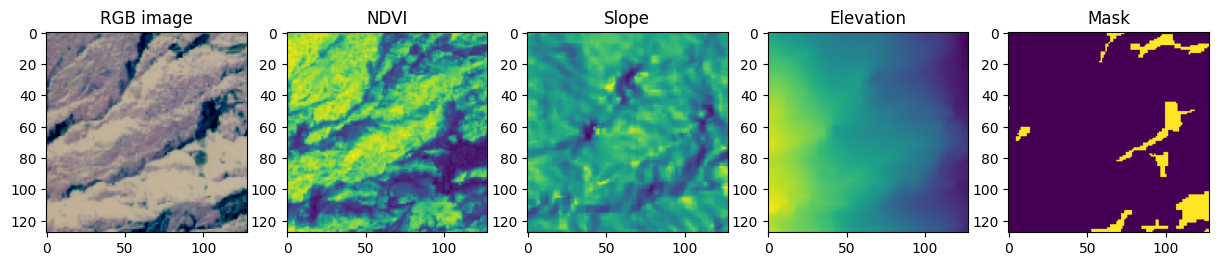

In [ ]:
img=234
fig,(ax1,ax2, ax3, ax4, ax5)= plt.subplots(1,5,figsize=(15,10))


ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")
ax1.imshow(TRAIN_XX[img, :, :, 0:3])
ax2.imshow(TRAIN_XX[img, :, :, 3])
ax3.imshow(TRAIN_XX[img, :, :, 4])
ax4.imshow(TRAIN_XX[img, :, :, 5])
ax5.imshow(TRAIN_YY[img, :, :, 0])

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
x_train, x_valid, y_train, y_valid = train_test_split(TRAIN_XX, TRAIN_YY, test_size=0.2, shuffle= True)

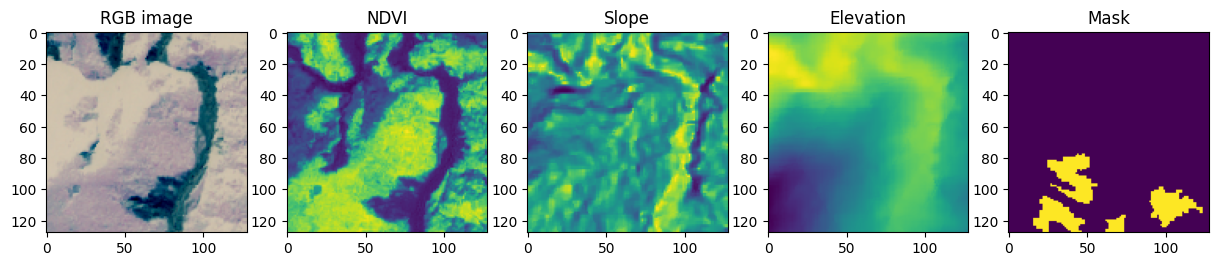

In [ ]:
img=1545
fig,(ax1,ax2, ax3, ax4, ax5)= plt.subplots(1,5,figsize=(15,10))

ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")
ax1.imshow(x_train[img, :, :, 0:3])
ax2.imshow(x_train[img, :, :, 3])
ax3.imshow(x_train[img, :, :, 4])
ax4.imshow(x_train[img, :, :, 5])
ax5.imshow(y_train[img, :, :, 0])

In [ ]:
x_train.shape, y_train.shape

((3039, 128, 128, 6), (3039, 128, 128, 1))

In [ ]:
# to release some memory, delete the unnecessary variable
del TRAIN_XX
del TRAIN_YY
del all_train
del all_mask

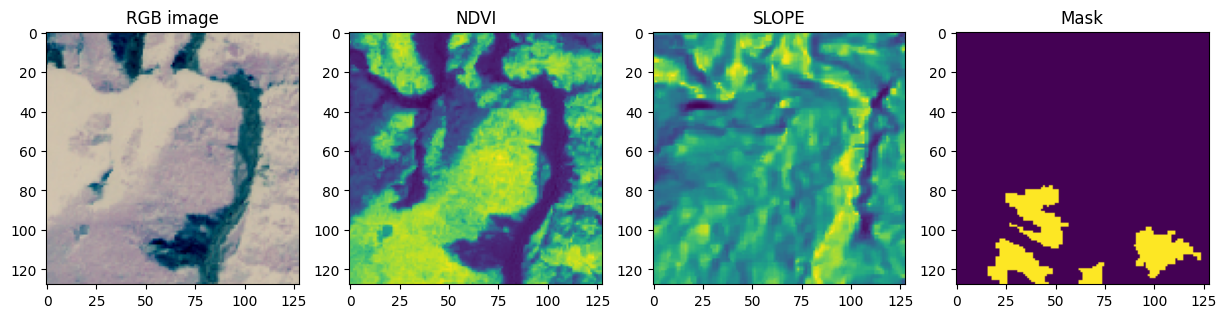

In [ ]:
img=1545
fig,(ax1,ax2, ax3, ax4)= plt.subplots(1,4,figsize=(15,10))


ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("SLOPE")
ax4.set_title("Mask")
ax1.imshow(x_train[img, :, :, 0:3])
ax2.imshow(x_train[img, :, :, 3])
ax3.imshow(x_train[img, :, :, 4])
ax4.imshow(y_train[img, :, :, 0])

In [ ]:
from utils import recall_m, precision_m, f1_m
def unet_model(IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS):
    inputs = tf.keras.layers.Input((IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS))

    # Converted inputs to floating
    #s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)


    #Contraction path
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy', tf.keras.metrics.Precision(),tf.keras.metrics.Recall(), f1_m])


    return model

In [ ]:
model = unet_model(128, 128, 6)
# model.summary()
checkpointer = tf.keras.callbacks.ModelCheckpoint("best_model.h5", monitor="val_f1_m", verbose=1, save_best_only=True, mode="max")
# earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_m', patience=10, verbose=1, mode='max')

callbacks = [
    # earlyStopping,
    checkpointer
    ]
history = model.fit(x_train, y_train, batch_size=16,
          epochs=100,
          verbose = 2,
          validation_data=(x_valid, y_valid),
          callbacks=callbacks)

model.save("model_save.h5")

Epoch 1/100

Epoch 1: val_f1_m improved from None to 0.07172, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
190/190 - 60s - 317ms/step - accuracy: 0.6734 - f1_m: 0.0587 - loss: 0.9536 - precision_3: 0.0324 - recall_3: 0.4489 - val_accuracy: 0.7414 - val_f1_m: 0.0717 - val_loss: 0.9540 - val_precision_3: 0.0381 - val_recall_3: 0.4314
Epoch 2/100

Epoch 2: val_f1_m improved from 0.07172 to 0.07459, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
190/190 - 9s - 46ms/step - accuracy: 0.7310 - f1_m: 0.0637 - loss: 0.9532 - precision_3: 0.0351 - recall_3: 0.3969 - val_accuracy: 0.7942 - val_f1_m: 0.0746 - val_loss: 0.9542 - val_precision_3: 0.0409 - val_recall_3: 0.3619
Epoch 3/100

Epoch 3: val_f1_m did not improve from 0.07459
190/190 - 9s - 48ms/step - accuracy: 0.7594 - f1_m: 0.0639 - loss: 0.9534 - precision_3: 0.0365 - recall_3: 0.3661 - val_accuracy: 0.7338 - val_f1_m: 0.0589 - val_loss: 0.9549 - val_precision_3: 0.0335 - val_recall_3: 0.3878
Epoch 4/100

Epoch 4: val_f1_m did not improve from 0.07459
190/190 - 8s - 44ms/step - accuracy: 0.7548 - f1_m: 0.0636 - loss: 0.9535 - precision_3: 0.0347 - recall_3: 0.3538 - val_accuracy: 0.6687 - val_f1_m: 0.0639 - val_loss: 0.9542 - val_precision_3: 0.0336 - val_recall_3: 0.4939
Epoch 5/100

Epoch 5: val_f1_m improved from 0.07459 to 0.07554, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
190/190 - 10s - 51ms/step - accuracy: 0.7310 - f1_m: 0.0646 - loss: 0.9530 - precision_3: 0.0359 - recall_3: 0.4064 - val_accuracy: 0.8111 - val_f1_m: 0.0755 - val_loss: 0.9543 - val_precision_3: 0.0421 - val_recall_3: 0.3393
Epoch 6/100

Epoch 6: val_f1_m did not improve from 0.07554
190/190 - 9s - 47ms/step - accuracy: 0.7430 - f1_m: 0.0657 - loss: 0.9530 - precision_3: 0.0366 - recall_3: 0.3946 - val_accuracy: 0.7265 - val_f1_m: 0.0681 - val_loss: 0.9541 - val_precision_3: 0.0364 - val_recall_3: 0.4367
Epoch 7/100

Epoch 7: val_f1_m did not improve from 0.07554
190/190 - 8s - 44ms/step - accuracy: 0.7248 - f1_m: 0.0649 - loss: 0.9531 - precision_3: 0.0358 - recall_3: 0.4151 - val_accuracy: 0.7662 - val_f1_m: 0.0708 - val_loss: 0.9542 - val_precision_3: 0.0385 - val_recall_3: 0.3910
Epoch 8/100

Epoch 8: val_f1_m did not improve from 0.07554
190/190 - 8s - 44ms/step - accuracy: 0.7401 - f1_m: 0.0683 - loss: 0.9528 - precision_3: 0.0370

In [ ]:
loss, accuracy, f1_score, precision, recall = model.evaluate(x_valid, y_valid, verbose=0)
print(loss, accuracy, f1_score, precision, recall)

0.9564210772514343 0.02254413813352585 0.02254413813352585 1.0 0.04413794353604317


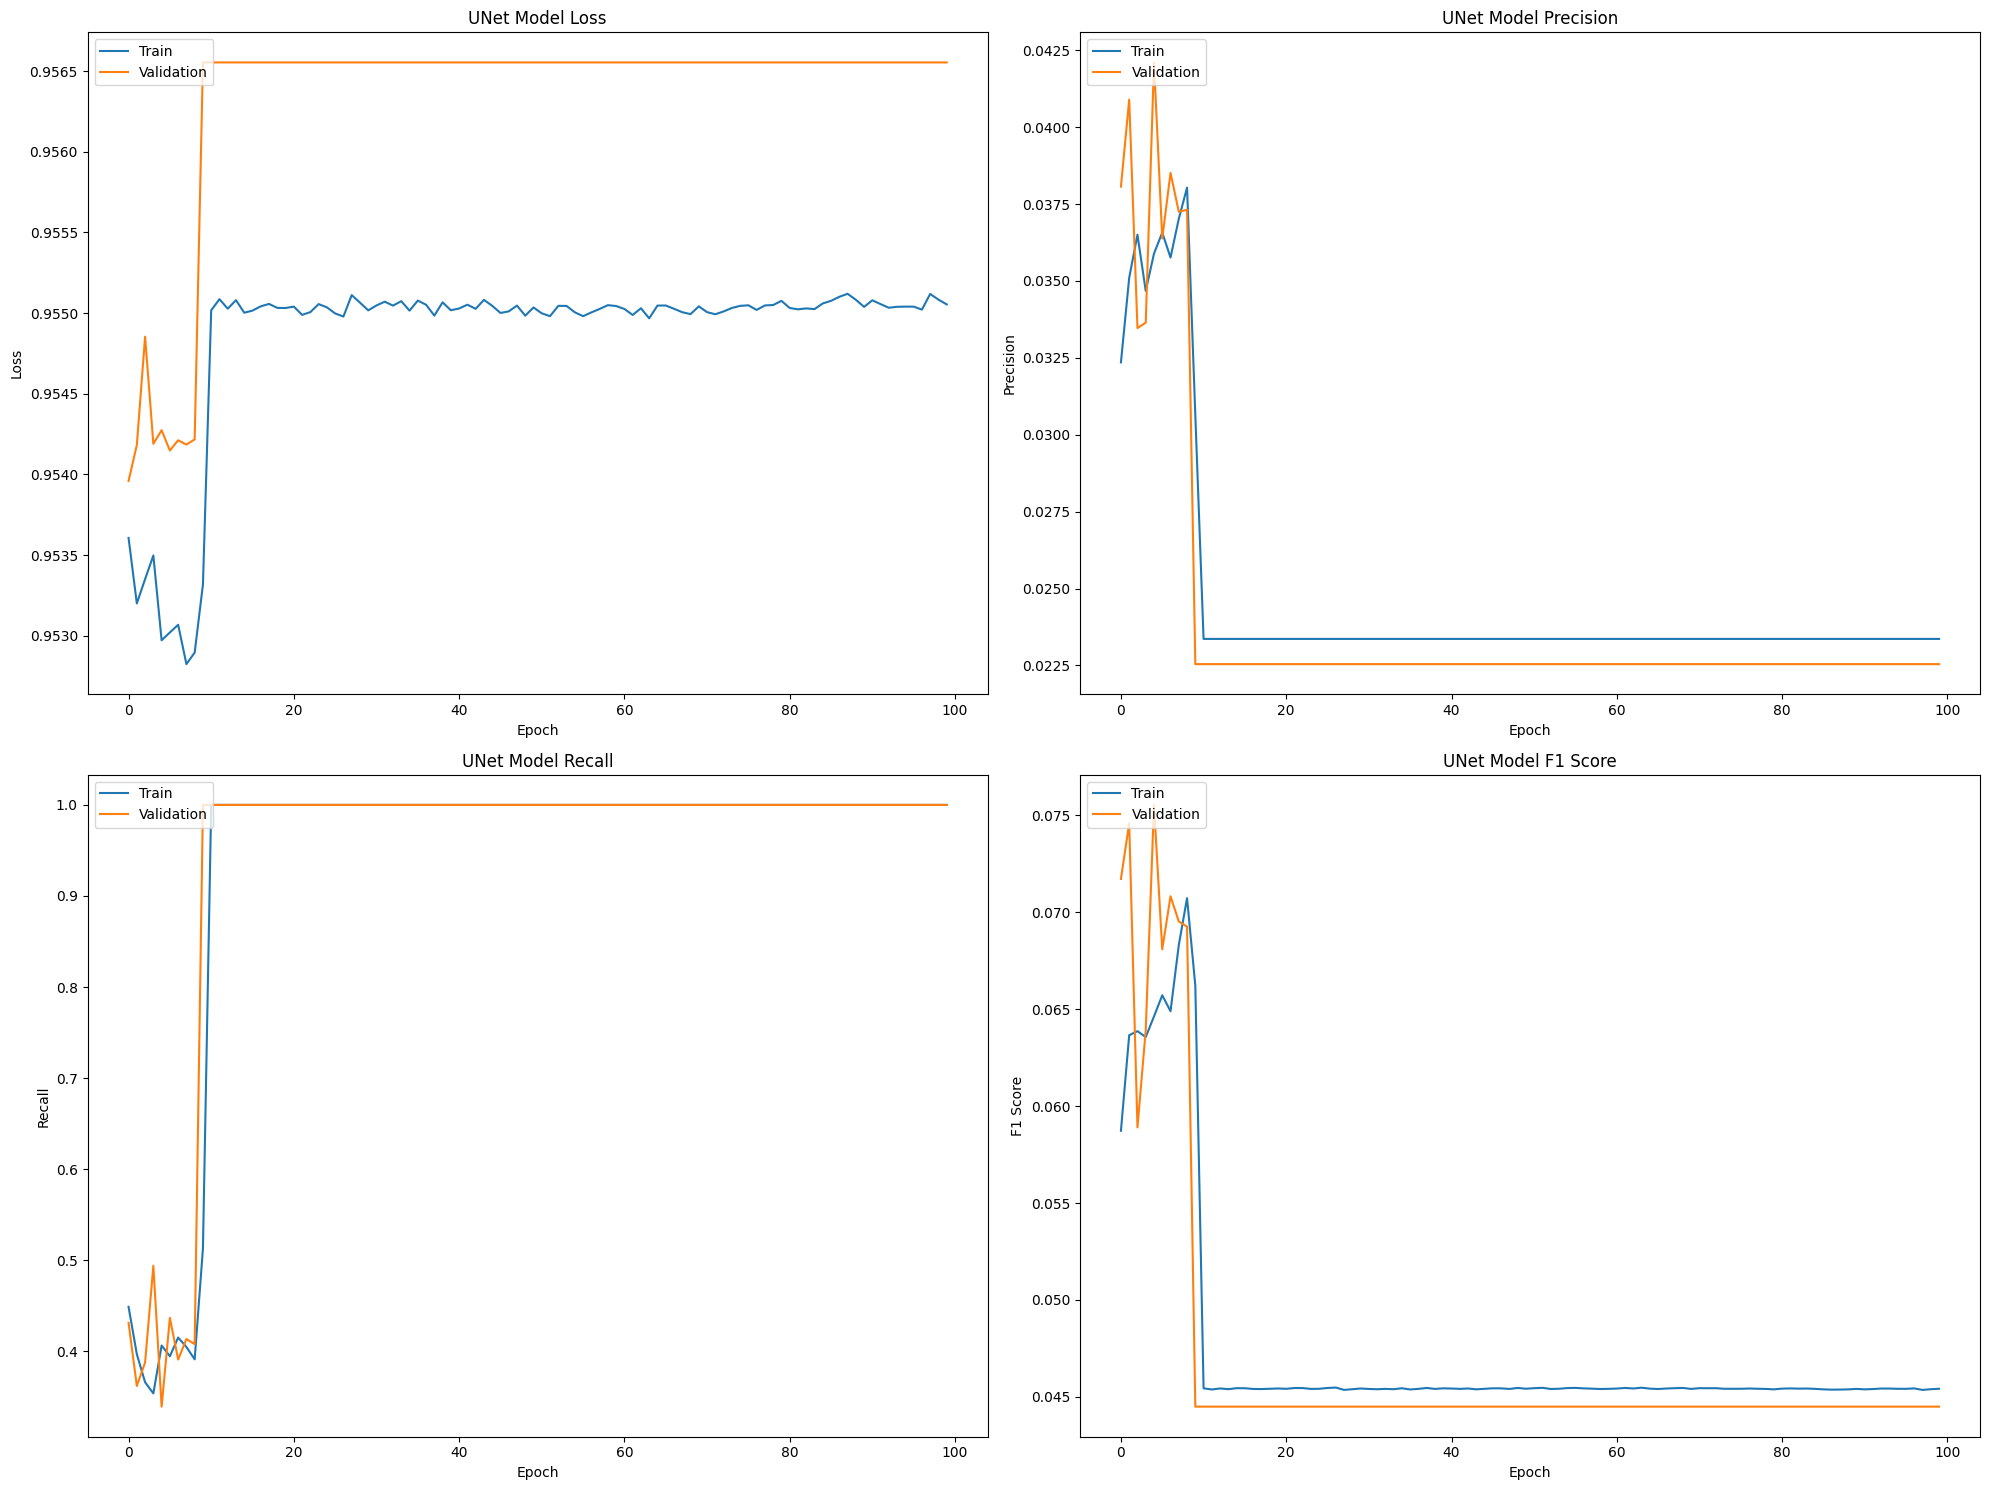

In [ ]:
import matplotlib.pyplot as plt

fig, ((ax11, ax12), (ax13, ax14)) = plt.subplots(2, 2, figsize=(20, 15))

# Loss
ax11.plot(history.history['loss'])
ax11.plot(history.history['val_loss'])
ax11.set_title('UNet Model Loss')
ax11.set_ylabel('Loss')
ax11.set_xlabel('Epoch')
ax11.legend(['Train', 'Validation'], loc='upper left')

# Precision
ax12.plot(history.history['precision_3'])
ax12.plot(history.history['val_precision_3'])
ax12.set_title('UNet Model Precision')
ax12.set_ylabel('Precision')
ax12.set_xlabel('Epoch')
ax12.legend(['Train', 'Validation'], loc='upper left')

# Recall
ax13.plot(history.history['recall_3'])
ax13.plot(history.history['val_recall_3'])
ax13.set_title('UNet Model Recall')
ax13.set_ylabel('Recall')
ax13.set_xlabel('Epoch')
ax13.legend(['Train', 'Validation'], loc='upper left')

# F1 Score
ax14.plot(history.history['f1_m'])
ax14.plot(history.history['val_f1_m'])
ax14.set_title('UNet Model F1 Score')
ax14.set_ylabel('F1 Score')
ax14.set_xlabel('Epoch')
ax14.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.5
pred_img = model.predict(x_valid)
pred_img = (pred_img > threshold).astype(np.uint8)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


Loaded model weights from best_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


Text(0.5, 1.0, 'Training Image')

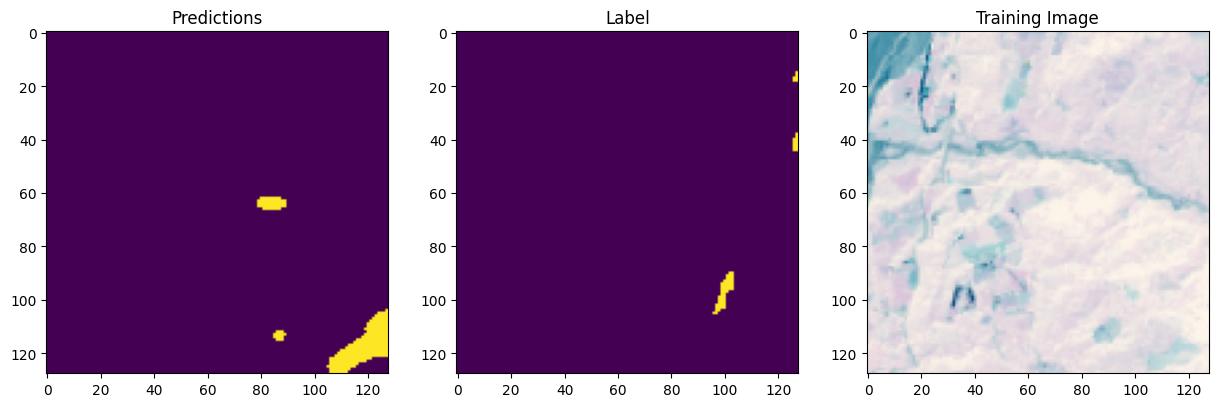

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import keras.backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

def dice_loss(y_true, y_pred):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.math.sigmoid(y_pred)
  numerator = 2 * tf.reduce_sum(y_true * y_pred)
  denominator = tf.reduce_sum(y_true + y_pred)
  return 1 - numerator / denominator

def unet_model(IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS):
    inputs = tf.keras.layers.Input((IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS))

    # Converted inputs to floating
    #s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)


    #Contraction path
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy', tf.keras.metrics.Precision(),tf.keras.metrics.Recall(), f1_m])

    return model


# Re-instantiate the model (assuming unet_model is defined in an executed cell)
model = unet_model(128, 128, 6)

# Try to load the best saved weights if available, otherwise the model will be untrained.
try:
    model.load_weights("best_model.h5")
    print("Loaded model weights from best_model.h5")
except:
    print("Could not load best_model.h5. Model might be untrained or partially trained.")

threshold = 0.5
pred_img = model.predict(x_valid)
pred_img = (pred_img > threshold).astype(np.uint8)

img = landslide_index # Use the found index with landslides
fig,(ax1,ax2,ax3)= plt.subplots(1,3,figsize=(15,10))
ax1.imshow(pred_img[img, :, :, 0])
ax1.set_title("Predictions")
ax2.imshow(y_valid[img, :, :, 0])
ax2.set_title("Label")

# Normalize the RGB image data for display to a [0, 1] range
rgb_display_data = x_valid[img, :, :, 0:3].copy()
rgb_min = np.min(rgb_display_data)
rgb_max = np.max(rgb_display_data)
if (rgb_max - rgb_min) > 0:
    scaled_rgb_display = (rgb_display_data - rgb_min) / (rgb_max - rgb_min)
else:
    scaled_rgb_display = rgb_display_data # Handle case where all values are the same

ax3.imshow(scaled_rgb_display)
ax3.set_title('Training Image')

In [ ]:
validation_url = r'/content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/*.h5'
img_val = sorted(glob.glob(validation_url))

VAL_XX = np.zeros((245, 128, 128, 6))
mask_name = []
for i, img in enumerate(img_val):
    print(i, img)
    mask_name.append(img.split('/')[-1].replace('image', 'mask'))
    with h5py.File(img) as hdf:
        ls = list(hdf.keys())
        data = np.array(hdf.get('img'))

        # assign 0 for the nan value
        data[np.isnan(data)] = 0.000001

        # to normalize the data
        mid_rgb = data[:, :, 1:4].max() / 2.0
        mid_slope = data[:, :, 12].max() / 2.0
        mid_elevation = data[:, :, 13].max() / 2.0

        # ndvi calculation
        data_red = data[:, :, 3]
        data_nir = data[:, :, 7]
        data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))

        # final array
        VAL_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb #RED
        VAL_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb #GREEN
        VAL_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb #BLUE
        VAL_XX[i, :, :, 3] = data_ndvi #NDVI
        VAL_XX[i, :, :, 4] = 1- data[:, :, 13] / mid_slope #SLOPE
        VAL_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation #ELEVATION

0 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_1.h5
1 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_10.h5
2 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_100.h5
3 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_101.h5
4 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_102.h5
5 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_103.h5
6 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_104.h5
7 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_105.h5
8 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_106.h5
9 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_107.h5
10 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_108.h5
11 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_109.h5
12 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img

/tmp/ipykernel_1734/1587217555.py:24: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))


166 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_28.h5
167 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_29.h5
168 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_3.h5
169 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_30.h5
170 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_31.h5
171 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_32.h5
172 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_33.h5
173 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_34.h5
174 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_35.h5
175 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_36.h5
176 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_37.h5
177 /content/gdrive/MyDrive/DL/landslide4Sense/data/validation/img/image_38.h5
178 /content/gdrive/MyDrive/DL/landslide4Sense/data/v

In [ ]:
threshold = 0.5
pred_img = model.predict(VAL_XX)
pred_img = (pred_img > threshold).astype(np.uint8)
pred_img.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


(245, 128, 128, 1)

In [ ]:
landslide_index = -1
for i in range(len(y_valid)):
    if np.sum(y_valid[i, :, :, 0]) > 0:
        landslide_index = i
        break

if landslide_index != -1:
    print(f"Found an image with landslides at index: {landslide_index}")
else:
    print("No images with landslides found in the validation set (y_valid).")

Found an image with landslides at index: 2


Text(0.5, 1.0, 'Validation Image')

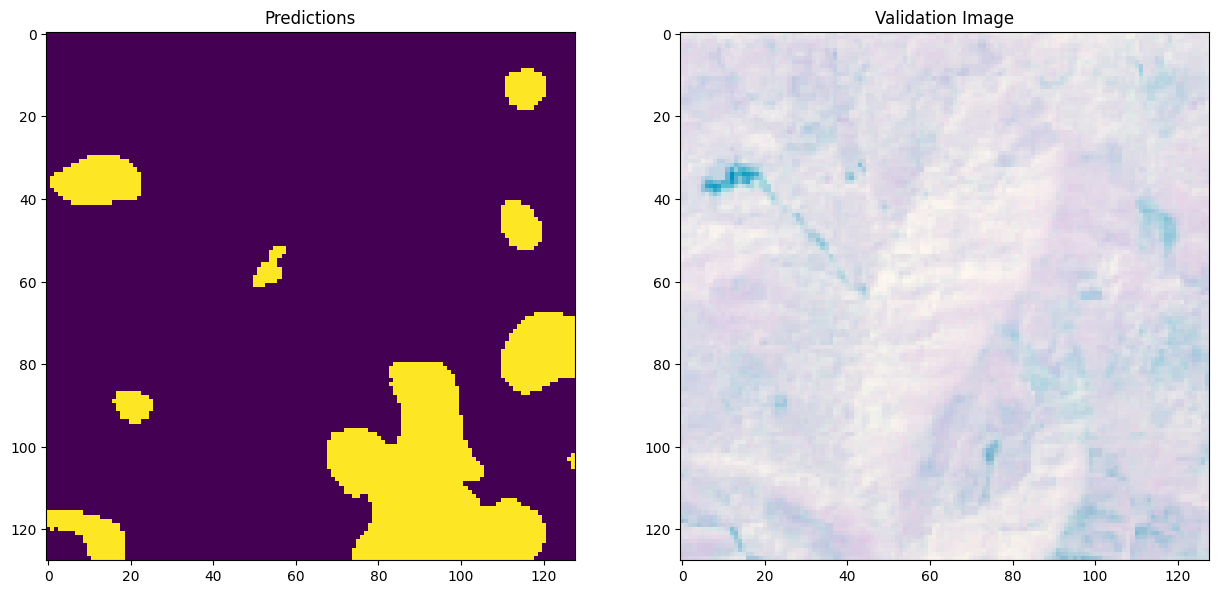

In [ ]:
img = landslide_index # Use the found index with landslides
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(15,10))
ax1.imshow(pred_img[img, :, :, 0])
ax1.set_title("Predictions")

# Normalize the RGB image data for display to a [0, 1] range
rgb_display_data_val = VAL_XX[img, :, :, 0:3].copy()
rgb_min_val = np.min(rgb_display_data_val)
rgb_max_val = np.max(rgb_display_data_val)
if (rgb_max_val - rgb_min_val) > 0:
    scaled_rgb_display_val = (rgb_display_data_val - rgb_min_val) / (rgb_max_val - rgb_min_val)
else:
    scaled_rgb_display_val = rgb_display_data_val # Handle case where all values are the same

ax2.imshow(scaled_rgb_display_val)
ax2.set_title('Validation Image')

In [ ]:
img_index = 2 # The image index used in the plotting cell

# Check the unique values and sum of predicted pixels
print(f"Predicted Image (pred_img) at index {img_index}:")
print(f"  Unique values: {np.unique(pred_img[img_index, :, :, 0])}")
print(f"  Sum of predicted positive pixels: {np.sum(pred_img[img_index, :, :, 0])}")

# Check the unique values and sum of true label pixels
print(f"True Label (y_valid) at index {img_index}:")
print(f"  Unique values: {np.unique(y_valid[img_index, :, :, 0])}")
print(f"  Sum of true positive pixels: {np.sum(y_valid[img_index, :, :, 0])}")


Predicted Image (pred_img) at index 2:
  Unique values: [0 1]
  Sum of predicted positive pixels: 2325
True Label (y_valid) at index 2:
  Unique values: [0. 1.]
  Sum of true positive pixels: 71.0


In [ ]:
import os

written_files = os.listdir(write_directory)

# Filter for .h5 files, as mask_name contains .h5
written_mask_files = [f for f in written_files if f.endswith('.h5')]

print(f"Expected {len(mask_name)} mask files to be written.")
print(f"Found {len(written_mask_files)} .h5 files in '{write_directory}'.")

# Check if all expected files are present
missing_files = [name for name in mask_name if name not in written_mask_files]

if not missing_files:
    print("All expected HDF5 mask files were found in the directory.")
else:
    print(f"The following {len(missing_files)} HDF5 mask files are missing: {missing_files}")

Expected 245 mask files to be written.
Found 245 .h5 files in '/content/gdrive/MyDrive/DL/landslide4Sense/data/validation/mask'.
All expected HDF5 mask files were found in the directory.
